In [34]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
from pathlib import Path
import normflows as nf

import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
num_batches = 200

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/uni_1e7/')

current_list = []
sem_list = []
voltage_list = []
input_idx = 0 # input_idx AFTER sorting out the output electrode
output_idx = 0

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltage_list.append(batch['inputs']) 

    if batch['currents'].ndim != 1:
        current_list.append(batch['currents'][:, output_idx])
        sem_list.append(batch['sem'][:, output_idx])
    else:
        current_list.append(batch['currents'])
        sem_list.append(batch['sem'])

# You need to change this if you changed simulation parameters

current_set = np.concatenate(current_list)
sem_set = np.concatenate(sem_list)
voltage_set = np.concatenate(voltage_list)[:, 1:]

print('Dataset loaded')

print(len(voltage_set))
print(len(current_set))
print(len(sem_set))

Dataset loaded
200000
200000
200000


In [45]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data import random_split
from train_sm import MakeDataset

train_size = 0.8
val_size = 0.1
test_size = 0.1

V = torch.from_numpy(voltage_set).float()
C = torch.from_numpy(current_set.reshape(-1, 1)).float()

num_samples = 100000
V = V[:num_samples, ...]
C = C[:num_samples, ...]

print(current_set.max(), current_set.min())

print(V.shape)
print(C.shape)

dataset = TensorDataset(V, C)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

# ---- compute mean/std on training subset only ----
train_idx = train_ds.indices
V_train = V[train_idx]
C_train = C[train_idx]

eps = 1e-6
V_mean = V_train.mean(dim=0, keepdim=True)          # [1, 8]
V_std  = V_train.std(dim=0, keepdim=True, unbiased=False) + eps     # [1, 8]

C_mean = C_train.mean(dim=0, keepdim=True)          # [1, 1]
C_std  = C_train.std(dim=0, keepdim=True, unbiased=False) + eps     # [1, 1]

# ---- standardize full tensors using train stats ----
Vz = (V - V_mean) / V_std
Cz = (C - C_mean) / C_std

# ---- rebuild datasets with standardized tensors ----
train_ds = TensorDataset(Vz[train_idx], Cz[train_idx])
val_idx  = val_ds.indices
test_idx = test_ds.indices
val_ds   = TensorDataset(Vz[val_idx],  Cz[val_idx])
test_ds  = TensorDataset(Vz[test_idx], Cz[test_idx])

batch_size = 2048
num_workers = 4
pin_memory = True
persistent_workers=True
prefetch_factor = 4

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
test_loader = DataLoader(
    test_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))
print('Dataloaders ready')

0.29758728654153654 -0.2975530629484989
torch.Size([100000, 7])
torch.Size([100000, 1])
80000
10000
10000
Dataloaders ready


In [46]:
K = 3
hidden_layers = 3   
hidden_units = 64   
num_context_dims = 1
v_dim = 7

flows = []
for i in range(K):
    flows += [
        nf.flows.CoupledRationalQuadraticSpline(
            v_dim,
            hidden_layers,
            hidden_units,
            num_context_channels=num_context_dims
        ),
        # Linear mixing between blocks
        nf.flows.LULinearPermute(v_dim),
    ]

# Diagonal Gaussian base
q0 = nf.distributions.DiagGaussian(v_dim, trainable=False)

nfm = nf.ConditionalNormalizingFlow(q0=q0, flows=flows)
nfm = nfm.to(device)

print('Coupling spline flow model created')

Coupling spline flow model created


In [47]:
num_epochs = 200

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-4)

train_losses = []
val_losses = []

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        nfm.train()
        train_loss = 0.0
        n_train = 0
        for v, c in train_loader:

            v = v.to(device, non_blocking=True)       
            c = c.to(device, non_blocking=True)
    
            loss = nfm.forward_kld(v, context=c)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            batch_size = v.size(0)
            train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss /= n_train
        train_losses.append(train_loss)
    
        nfm.eval()
        val_loss = 0.0
        n_val = 0
    
        with torch.no_grad():
            for v_val, c_val in val_loader:
                v_val = v_val.to(device, non_blocking=True)
                c_val = c_val.to(device, non_blocking=True)
    
                loss_val = nfm.forward_kld(v_val, context=c_val)
                
                batch_size = v_val.size(0)
                val_loss += loss_val.item() * batch_size
                n_val += batch_size
    
        val_loss /= n_val
        val_losses.append(val_loss)
    
        pbar.set_postfix({
            "Epoch": f"{epoch:03d}",
            "train NLL": f"{train_loss:.4f}",
            "val NLL": f"{val_loss:.4f}"
        })
        pbar.update(1)

print('Training is Done')

Epochs: 100%|██████████| 200/200 [09:58<00:00,  2.99s/it, Epoch=200, train NLL=6.4580, val NLL=6.4803]

Training is Done


Test NLL: 6.48509404296875
logp: -6.510329723358154 logp_shuffled: -29.319622039794922


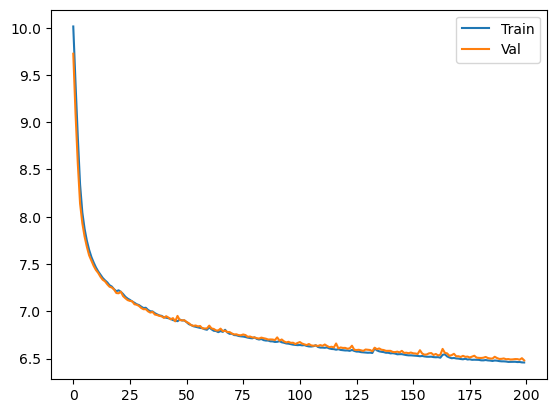

In [51]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()

nfm.eval()
nll_sum, n = 0.0, 0
with torch.no_grad():
    for v, c in test_loader:
        v, c = v.to(device), c.to(device)
        v = v.view(v.size(0), -1)
        nll = -nfm.log_prob(v, context=c)   # shape [B]
        nll_sum += nll.sum().item()
        n += v.size(0)
print("Test NLL:", nll_sum / n)

with torch.no_grad():
    v, c = next(iter(test_loader))
    v, c = v.to(device), c.to(device)
    v = v.view(v.size(0), -1)
    lp = nfm.log_prob(v, context=c).mean().item()
    lp_shuf = nfm.log_prob(v, context=c[torch.randperm(c.size(0))]).mean().item()
print("logp:", lp, "logp_shuffled:", lp_shuf)